# 05 Rule-based 분류 (SBC)

**목적:** 165개 type×family 주간 시계열에 **SBC(Syntetos-Boylan Classification)** 규칙을 적용해 4분류합니다.

| 클러스터 | 조건 | 의미 |
|----------|------|------|
| 1 Smooth | ADI<1.32, CV²<0.49 | 연속·안정 수요 |
| 2 Intermittent | ADI≥1.32, CV²<0.49 | 간헐·저변동 |
| 3 Erratic | ADI<1.32, CV²≥0.49 | 연속·고변동 |
| 4 Lumpy | ADI≥1.32, CV²≥0.49 | 간헐·고변동 |

**산출물:** `sbc_cluster_type_family.parquet`


### ⓪ 환경 설정 및 SBC 계산

주간 데이터에서 type×family별 **ADI**(Average Demand Interval), **CV²**를 계산해 4분류 라벨을 부여합니다.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# 경로 설정
NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'code' else NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'code'))
from utils.paths import DATA_PROCESSED, SBC_CLUSTER
from utils.sbc import compute_sbc_table, ADI_TH, CV2_TH, CLUSTER_LABELS

# SBC 4분류 계산 (임계값: ADI=1.32, CV²=0.49)
dfw = pd.read_parquet(DATA_PROCESSED / 'df_weekly.parquet')
sbc = compute_sbc_table(dfw, ['type', 'family'], qty_col='sales')
print(sbc['SBC_CLUSTER_LABEL'].value_counts())
sbc.head()


SBC_CLUSTER_LABEL
Smooth          95
Intermittent    45
Lumpy           14
Erratic         11
Name: count, dtype: int64


,type,family,ADI,CV2,SBC_CLUSTER,SBC_CLUSTER_LABEL,n_periods,n_positive
0,A,AUTOMOTIVE,1.000000,0.026484,1,Smooth,242,242
1,A,BABY CARE,NaN,NaN,4,Lumpy,242,0
2,A,BEAUTY,1.000000,0.142160,1,Smooth,242,242
3,A,BEVERAGES,1.000000,0.160200,1,Smooth,242,242
4,A,BOOKS,5.627907,1.108685,4,Lumpy,242,43


### ① type별 SBC 분포

5개 type 각각에서 Smooth/Intermittent/Erratic/Lumpy가 몇 개인지 교차표로 확인합니다.

In [2]:
# type × SBC 클러스터 교차표
print(sbc.groupby(['type', 'SBC_CLUSTER_LABEL']).size().unstack(fill_value=0))


SBC_CLUSTER_LABEL  Erratic  Intermittent  Lumpy  Smooth
type                                                   
A                        3             8      3      19
B                        2             9      3      19
C                        1            10      3      19
D                        3             9      2      19
E                        2             9      3      19


### ② ADI vs CV² 산점도

4분면 경계선(ADI=1.32, CV²=0.49)과 함께 시각화합니다. 각 점 = type×family 1개 시계열.

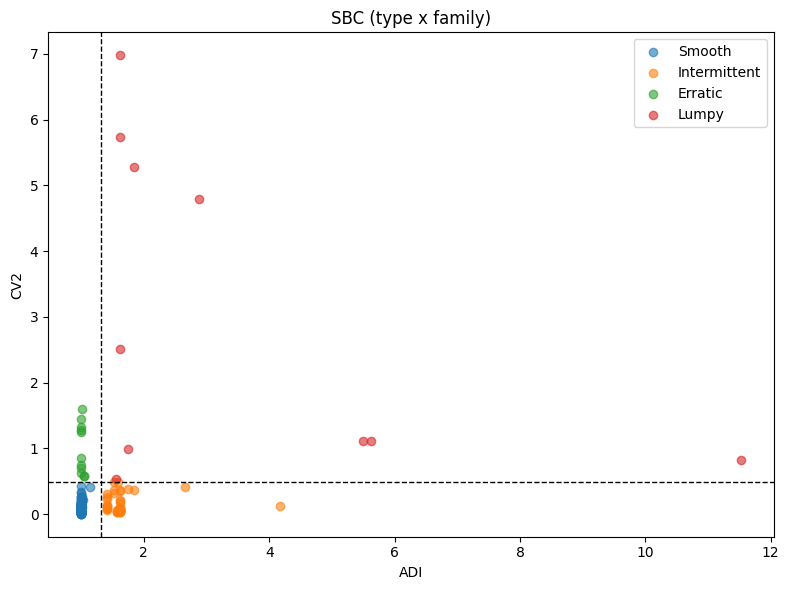

In [3]:
# ADI-CV² 4분면 산점도 (점 = type×family 1개 시계열)
plt.figure(figsize=(8, 6))
for cl, g in sbc.groupby('SBC_CLUSTER'):
    plt.scatter(g['ADI'], g['CV2'], alpha=0.6, label=CLUSTER_LABELS[cl])
plt.axvline(ADI_TH, color='k', ls='--', lw=1)   # ADI=1.32 경계
plt.axhline(CV2_TH, color='k', ls='--', lw=1)  # CV²=0.49 경계
plt.xlabel('ADI'); plt.ylabel('CV2'); plt.title('SBC (type x family)')
plt.legend(); plt.tight_layout(); plt.show()


### ③ SBC 라벨 저장

165개 시계열의 SBC 클러스터를 `sbc_cluster_type_family.parquet`에 저장합니다. 07~10장 예측 실험의 **조건 축**이 됩니다.

In [4]:
# SBC 라벨 parquet 저장 → 07~10장 예측 실험 조건 축
sbc.to_parquet(SBC_CLUSTER, index=False)
print('저장:', SBC_CLUSTER)


저장: C:\Users\kjh\ai-retail-demandforecasting\data\processed\sbc_cluster_type_family.parquet


## 분석 요약

### SBC 4분류 결과 (165 시계열)
| 클러스터 | 개수 | 비율 | 특성 |
|----------|------|------|------|
| **Smooth** | 95 | 57.6% | ADI<1.32, CV²<0.49 — 연속적·안정 수요 |
| **Intermittent** | 45 | 27.3% | ADI≥1.32, CV²<0.49 — 간헐적·저변동 |
| **Lumpy** | 14 | 8.5% | ADI≥1.32, CV²≥0.49 — 간헐적·고변동 |
| **Erratic** | 11 | 6.7% | ADI<1.32, CV²≥0.49 — 연속적·고변동 |

### type별 분포
- 5개 type 모두 **Smooth 19개**로 동일 (family 구성이 type마다 같기 때문)
- **Intermittent**는 C type에서 10개로 가장 많음
- **Lumpy**는 D type에서 2개로 가장 적음 → D type이 상대적으로 루미 수요 적음

### 시사점
- 전체의 **57%가 Smooth** → 연속 수요 모델(ARIMA, Prophet) 적용 후보가 많음
- **36%가 Intermittent+Lumpy** → SBA/TSB 같은 간헐 수요 모델 필요
- ADI-CV² scatter에서 4분면 경계(1.32, 0.49)가 논문 기준과 일치